# CodeAlpha — Machine Learning Internship
## Task 1: Credit Scoring Model

**Objective:** predict an individual's creditworthiness (probability of loan default) from past
financial data.

**Dataset:** `credit_risk_dataset.csv` — 32,581 loan applications with borrower demographics,
income, employment, loan characteristics and credit-bureau history.
Target: `loan_status` (1 = defaulted / bad credit risk, 0 = repaid / good credit risk).

**Approach**
1. Exploratory data analysis
2. Data cleaning (outliers, missing values, duplicates)
3. Feature engineering from financial history
4. Preprocessing pipeline (imputation, scaling, encoding)
5. Train four classifiers: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting
6. Evaluate with Accuracy, Precision, Recall, F1-Score and ROC-AUC
7. Hyperparameter tuning + decision-threshold optimisation of the best model
8. Feature importance and business interpretation

## 1. Imports and setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

print("Environment ready.")

Environment ready.


## 2. Load the data

In [2]:
CANDIDATE_PATHS = [
    "credit_risk_dataset.csv",
    "data/credit_risk_dataset.csv",
    "../data/credit_risk_dataset.csv",
    "/mnt/data/credit_risk_dataset.csv",
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "credit_risk_dataset.csv not found. Put it next to this notebook or edit CANDIDATE_PATHS."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded: credit_risk_dataset.csv
Shape : 32,581 rows x 12 columns


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


### Column dictionary

| Column | Meaning |
|---|---|
| `person_age` | Applicant age (years) |
| `person_income` | Annual income |
| `person_home_ownership` | RENT / OWN / MORTGAGE / OTHER |
| `person_emp_length` | Employment length (years) |
| `loan_intent` | Purpose of the loan |
| `loan_grade` | Internal credit grade A (best) → G (worst) |
| `loan_amnt` | Loan amount requested |
| `loan_int_rate` | Interest rate offered (%) |
| `loan_percent_income` | Loan amount / income |
| `cb_person_default_on_file` | Historical default on credit bureau file (Y/N) |
| `cb_person_cred_hist_length` | Length of credit history (years) |
| **`loan_status`** | **Target** — 1 = default, 0 = non-default |

## 3. Exploratory data analysis

In [4]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
summary

,dtype,missing,missing_%,n_unique
person_age,int64,0,0.00,58
person_income,int64,0,0.00,4295
person_home_ownership,str,0,0.00,4
person_emp_length,float64,895,2.75,36
loan_intent,str,0,0.00,6
loan_grade,str,0,0.00,7
loan_amnt,int64,0,0.00,753
loan_int_rate,float64,3116,9.56,348
loan_status,int64,0,0.00,2
loan_percent_income,float64,0,0.00,77


In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.73,6.35,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.85,61983.12,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.79,4.14,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.37,6322.09,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.01,3.24,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.22,0.41,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.17,0.11,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.80,4.06,2.00,3.00,4.00,8.00,30.00


Target distribution (loan_status)
  Non-default (0)  25,473  (78.18%)
  Default (1)       7,108  (21.82%)

Imbalance ratio: 1 default for every 3.58 non-defaults


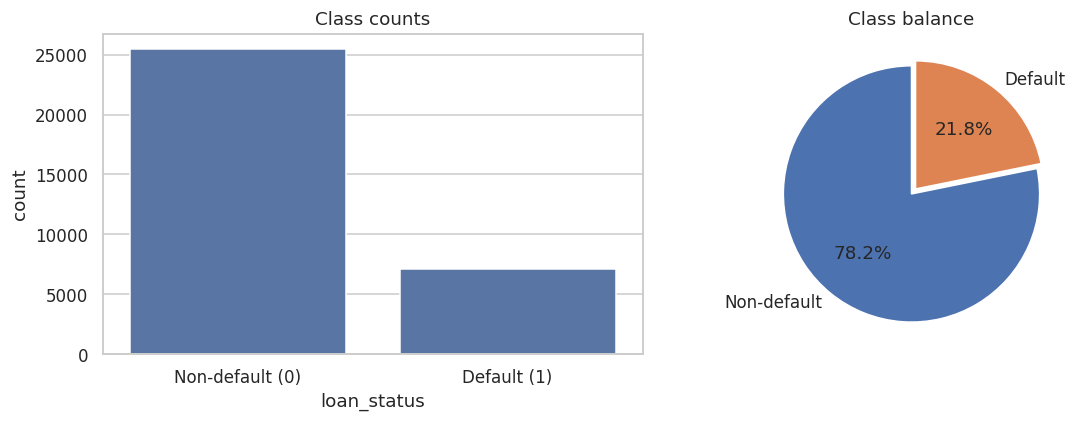

In [6]:
target_counts = df["loan_status"].value_counts().sort_index()
target_pct = df["loan_status"].value_counts(normalize=True).sort_index() * 100

print("Target distribution (loan_status)")
for k in target_counts.index:
    label = "Default (1)" if k == 1 else "Non-default (0)"
    print(f"  {label:<16} {target_counts[k]:>6,}  ({target_pct[k]:.2f}%)")
print(f"\nImbalance ratio: 1 default for every {target_counts[0]/target_counts[1]:.2f} non-defaults")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="loan_status", data=df, ax=ax[0])
ax[0].set_title("Class counts")
ax[0].set_xticklabels(["Non-default (0)", "Default (1)"])
ax[1].pie(target_counts, labels=["Non-default", "Default"], autopct="%1.1f%%",
          startangle=90, explode=(0, 0.05))
ax[1].set_title("Class balance")
plt.tight_layout(); plt.show()

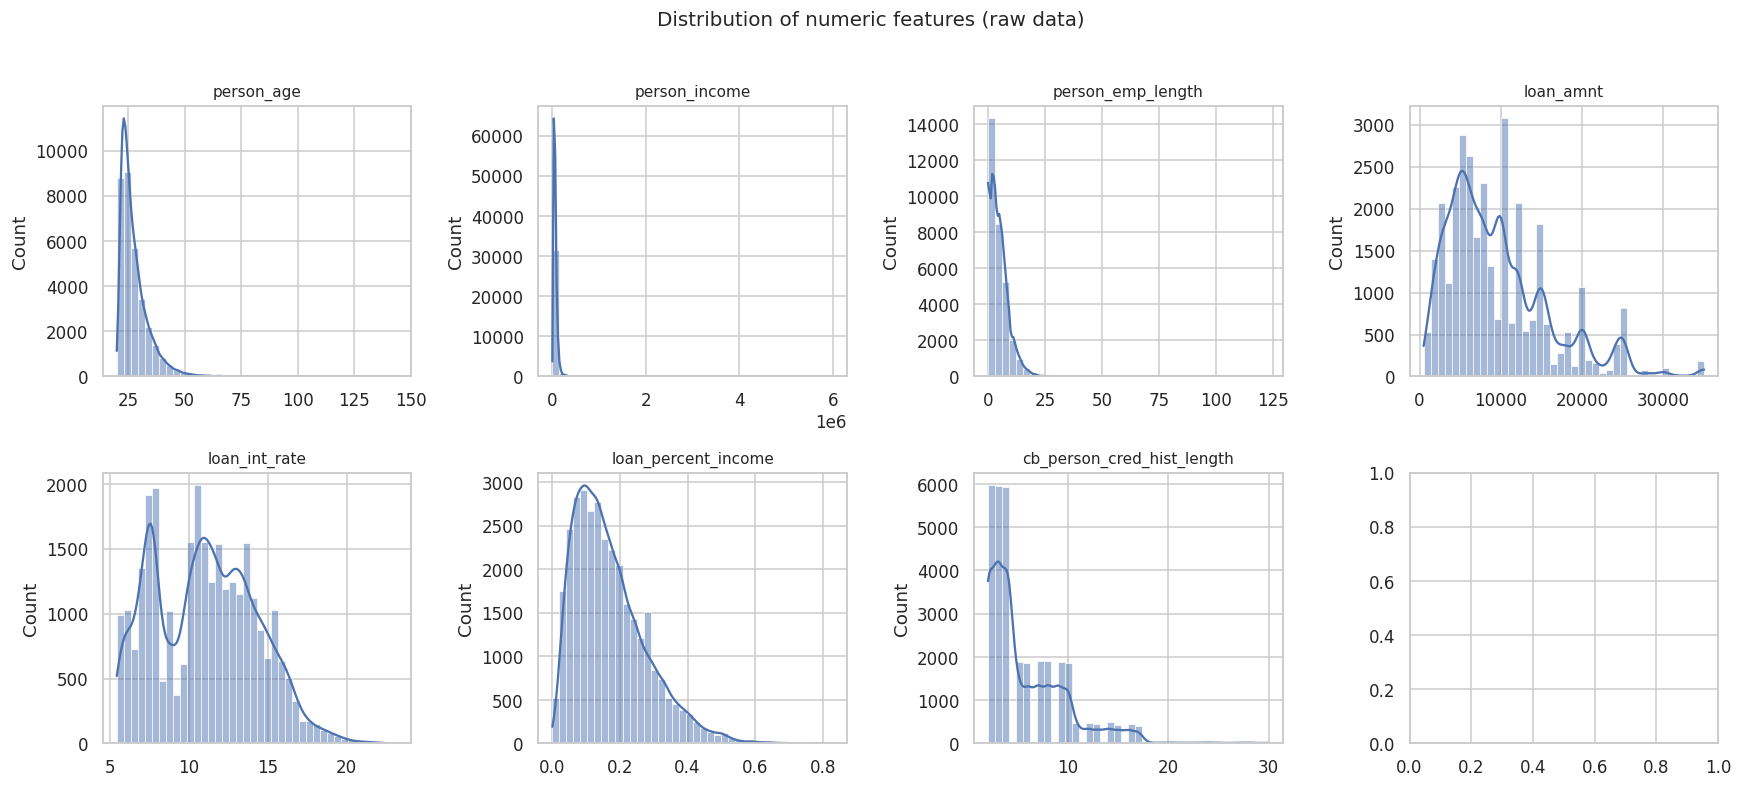

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.drop("loan_status")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Distribution of numeric features (raw data)", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

Three features show physically impossible values that must be handled before modelling:

* `person_age` reaches **144** years
* `person_emp_length` reaches **123** years (longer than any plausible career)
* `person_income` has an extreme right tail (up to 6,000,000)

In [8]:
print("Implausible records")
print(f"  age > 100                 : {(df['person_age'] > 100).sum()}")
print(f"  employment length > 60 yrs: {(df['person_emp_length'] > 60).sum()}")
print(f"  employment length > age    : {(df['person_emp_length'] > df['person_age']).sum()}")
print(f"  exact duplicate rows       : {df.duplicated().sum()}")

Implausible records
  age > 100                 : 5
  employment length > 60 yrs: 2
  employment length > age    : 2
  exact duplicate rows       : 165


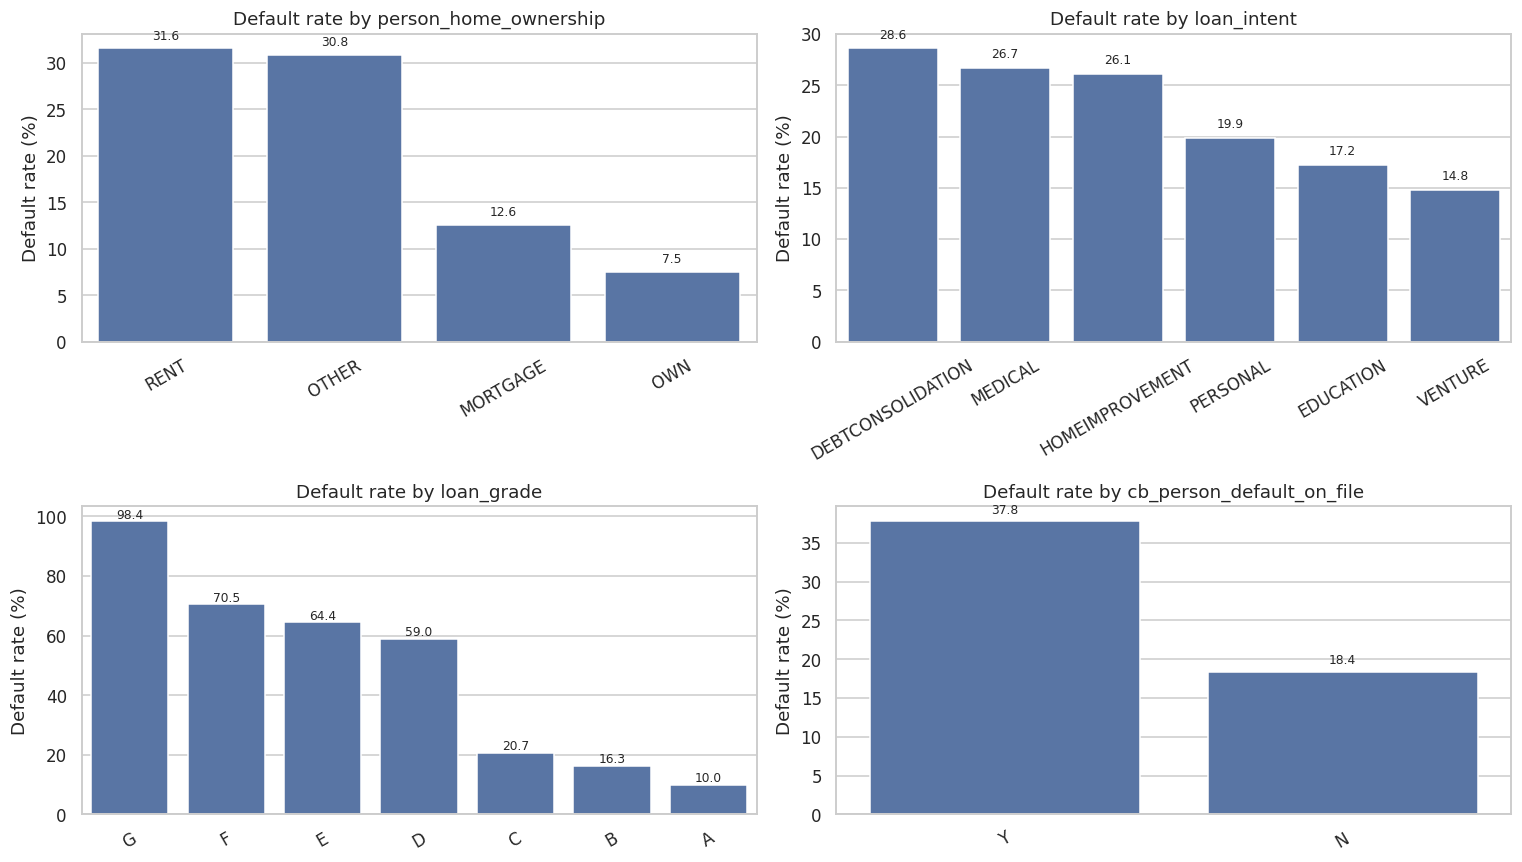

In [9]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = df.groupby(col)["loan_status"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f"Default rate by {col}")
    ax.set_ylabel("Default rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

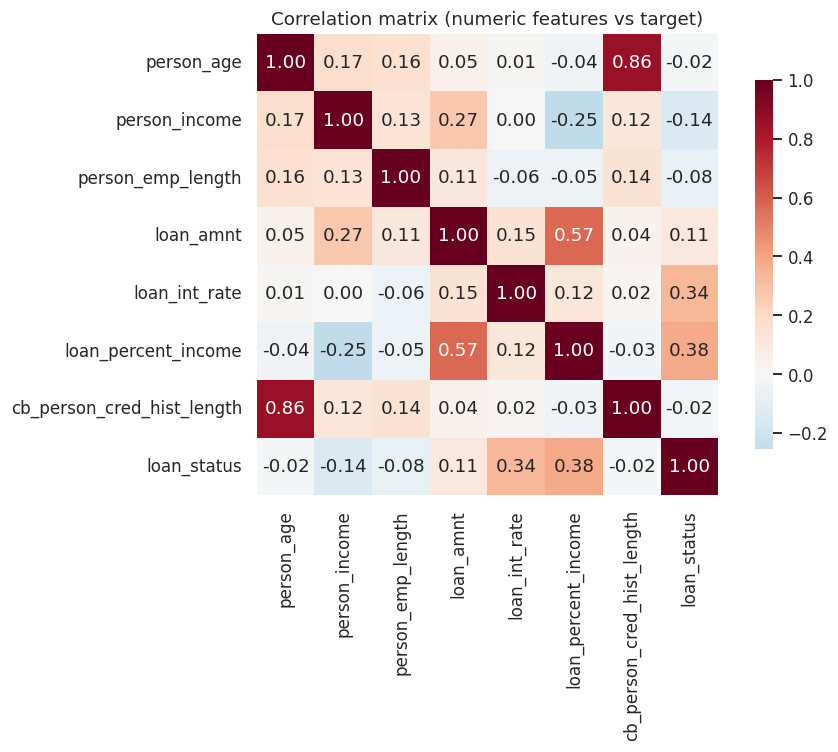

Correlation with loan_status, strongest first:
loan_percent_income           0.379
loan_int_rate                 0.335
person_income                 0.144
loan_amnt                     0.105
person_emp_length             0.082
person_age                    0.022
cb_person_cred_hist_length    0.016
Name: loan_status, dtype: float64


In [10]:
plt.figure(figsize=(9, 7))
corr = df[list(num_cols) + ["loan_status"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": .8})
plt.title("Correlation matrix (numeric features vs target)")
plt.tight_layout(); plt.show()

print("Correlation with loan_status, strongest first:")
print(corr["loan_status"].drop("loan_status").abs().sort_values(ascending=False).round(3))

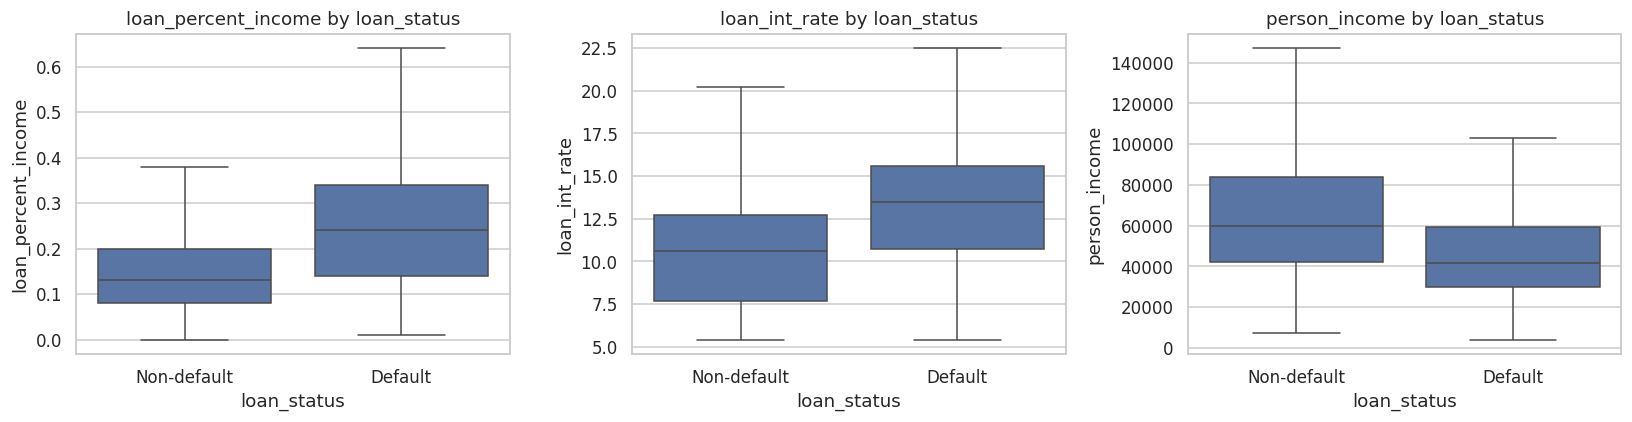

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["loan_percent_income", "loan_int_rate", "person_income"]):
    sns.boxplot(x="loan_status", y=col, data=df, ax=ax, showfliers=False)
    ax.set_title(f"{col} by loan_status")
    ax.set_xticklabels(["Non-default", "Default"])
plt.tight_layout(); plt.show()

**EDA takeaways**

* The target is imbalanced — roughly 21.8% defaults. Accuracy alone would be a misleading metric,
  so Recall, F1 and ROC-AUC are the ones to judge on.
* `loan_percent_income`, `loan_int_rate` and `loan_grade` carry the strongest signal: default rates
  climb steadily from grade A to grade G.
* Renters default far more than mortgage holders — home ownership is a strong categorical predictor.
* `loan_int_rate` (9.6% missing) and `person_emp_length` (2.7% missing) need imputation.

## 4. Data cleaning

In [12]:
df_clean = df.copy()
before = len(df_clean)

# Remove physically impossible ages and employment lengths (data-entry errors)
df_clean = df_clean[df_clean["person_age"] <= 100]
df_clean.loc[df_clean["person_emp_length"] > 60, "person_emp_length"] = np.nan
df_clean.loc[df_clean["person_emp_length"] > df_clean["person_age"], "person_emp_length"] = np.nan

# Cap extreme income at the 99.5th percentile rather than dropping high earners
income_cap = df_clean["person_income"].quantile(0.995)
df_clean["person_income"] = df_clean["person_income"].clip(upper=income_cap)

# Drop exact duplicates
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Rows before cleaning : {before:,}")
print(f"Rows after cleaning  : {len(df_clean):,}  ({before - len(df_clean):,} removed)")
print(f"Income capped at     : {income_cap:,.0f}")
print(f"Default rate retained: {df_clean['loan_status'].mean():.4f}")

Rows before cleaning : 32,581
Rows after cleaning  : 32,411  (170 removed)
Income capped at     : 300,000
Default rate retained: 0.2187


## 5. Feature engineering from financial history

Seven derived features are added to expose affordability, leverage and credit-maturity signals
that the raw columns only hint at.

In [13]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()

    # Annual interest burden and its share of income — true affordability
    d["annual_interest"] = d["loan_amnt"] * d["loan_int_rate"] / 100
    d["interest_to_income"] = d["annual_interest"] / d["person_income"].replace(0, np.nan)

    # Income left after servicing the loan
    d["disposable_income"] = d["person_income"] - d["loan_amnt"]

    # Leverage: loan size relative to income (log-scaled for skew)
    d["loan_to_income"] = d["loan_amnt"] / d["person_income"].replace(0, np.nan)
    d["log_income"] = np.log1p(d["person_income"])

    # Credit maturity: how much of adult life is covered by credit history / employment
    d["cred_hist_ratio"] = d["cb_person_cred_hist_length"] / (d["person_age"] - 17).clip(lower=1)
    d["emp_stability"] = d["person_emp_length"] / (d["person_age"] - 17).clip(lower=1)

    # Ordinal encoding of the credit grade (A=1 best ... G=7 worst)
    d["loan_grade_ord"] = d["loan_grade"].map({g: i for i, g in enumerate("ABCDEFG", start=1)})

    # Binary flag for prior default on file
    d["prior_default"] = (d["cb_person_default_on_file"] == "Y").astype(int)

    return d

df_feat = engineer_features(df_clean)
new_cols = [c for c in df_feat.columns if c not in df_clean.columns]
print("Engineered features:", new_cols)
df_feat[new_cols].describe().T.round(3)

Engineered features: ['annual_interest', 'interest_to_income', 'disposable_income', 'loan_to_income', 'log_income', 'cred_hist_ratio', 'emp_stability', 'loan_grade_ord', 'prior_default']


,count,mean,std,min,25%,50%,75%,max
annual_interest,29317.0,1086.389,879.040,48.800,475.600,820.050,1423.200,7087.500
interest_to_income,29317.0,0.019,0.014,0.000,0.009,0.015,0.026,0.115
disposable_income,32411.0,55269.565,38286.590,1450.000,30350.000,46000.000,68000.000,299000.000
loan_to_income,32411.0,0.171,0.107,0.003,0.090,0.148,0.229,0.830
log_income,32411.0,10.923,0.557,8.294,10.558,10.915,11.280,12.612
cred_hist_ratio,32411.0,0.534,0.182,0.222,0.400,0.500,0.667,1.333
emp_stability,31522.0,0.527,0.421,0.000,0.167,0.417,0.923,1.500
loan_grade_ord,32411.0,2.220,1.167,1.000,1.000,2.000,3.000,7.000
prior_default,32411.0,0.177,0.381,0.000,0.000,0.000,0.000,1.000


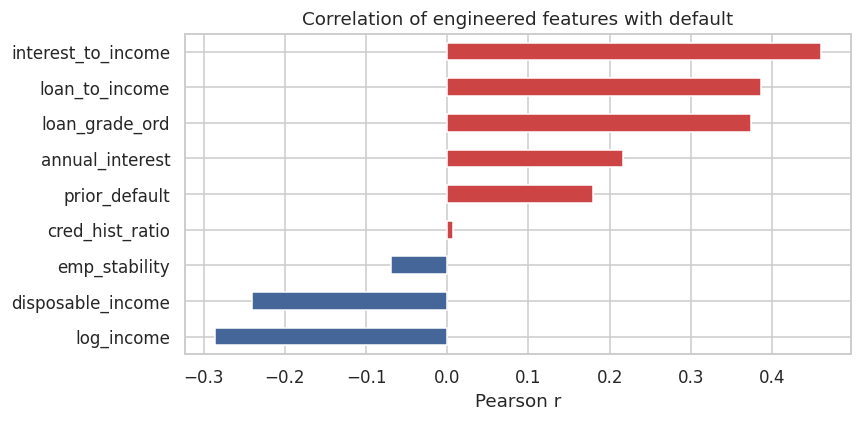

interest_to_income    0.460
loan_to_income        0.386
loan_grade_ord        0.373
log_income            0.286
disposable_income     0.240
annual_interest       0.216
prior_default         0.179
emp_stability         0.069
cred_hist_ratio       0.007
Name: loan_status, dtype: float64

In [14]:
eng_corr = df_feat[new_cols + ["loan_status"]].corr()["loan_status"].drop("loan_status")
plt.figure(figsize=(8, 4))
eng_corr.sort_values().plot(kind="barh", color=np.where(eng_corr.sort_values() > 0, "#c44", "#469"))
plt.title("Correlation of engineered features with default")
plt.xlabel("Pearson r")
plt.tight_layout(); plt.show()
eng_corr.abs().sort_values(ascending=False).round(3)

## 6. Train / test split and preprocessing pipeline

In [15]:
TARGET = "loan_status"
DROP = ["loan_grade", "cb_person_default_on_file"]  # replaced by ordinal / binary versions

X = df_feat.drop(columns=[TARGET] + DROP)
y = df_feat[TARGET]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Features: {X.shape[1]}  ({len(numeric_features)} numeric, {len(categorical_features)} categorical)")
print("Categorical:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"\nTrain: {X_train.shape[0]:,} rows | default rate {y_train.mean():.4f}")
print(f"Test : {X_test.shape[0]:,} rows | default rate {y_test.mean():.4f}")

Features: 18  (16 numeric, 2 categorical)
Categorical: ['person_home_ownership', 'loan_intent']



Train: 25,928 rows | default rate 0.2187
Test : 6,483 rows | default rate 0.2187


In [16]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()
print(f"Feature matrix after preprocessing: {len(feature_names)} columns")

Feature matrix after preprocessing: 24 columns


All imputation, scaling and encoding sit **inside** the pipeline, so statistics are learned on the
training fold only — no leakage into the test set or cross-validation folds.

## 7. Model training and evaluation

Four classification algorithms are trained on identical pipelines. Logistic Regression and Decision
Tree use `class_weight="balanced"` to offset the 78/22 imbalance; the ensembles are strong enough
that balancing is evaluated as a tuning choice instead.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=40, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=14, min_samples_leaf=3,
        n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE),
}

In [18]:
def evaluate(name, pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)
    y_prob = pipe.predict_proba(X_te)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred),
        "F1-Score": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_prob),
        "PR-AUC": average_precision_score(y_te, y_prob),
    }, y_pred, y_prob

results, predictions, probabilities, fitted = [], {}, {}, {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

for name, estimator in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", estimator)])
    pipe.fit(X_train, y_train)

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    row, y_pred, y_prob = evaluate(name, pipe, X_test, y_test)
    row["CV ROC-AUC (mean)"] = cv_auc.mean()
    row["CV ROC-AUC (std)"] = cv_auc.std()

    results.append(row)
    predictions[name], probabilities[name], fitted[name] = y_pred, y_prob, pipe
    print(f"{name:<22} test ROC-AUC {row['ROC-AUC']:.4f} | F1 {row['F1-Score']:.4f} | "
          f"CV AUC {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")

Logistic Regression    test ROC-AUC 0.8778 | F1 0.6401 | CV AUC 0.8803 +/- 0.0040


Decision Tree          test ROC-AUC 0.9113 | F1 0.7680 | CV AUC 0.9118 +/- 0.0046


Random Forest          test ROC-AUC 0.9241 | F1 0.8079 | CV AUC 0.9276 +/- 0.0008


Gradient Boosting      test ROC-AUC 0.9294 | F1 0.8171 | CV AUC 0.9330 +/- 0.0006


In [19]:
results_df = (pd.DataFrame(results)
              .set_index("Model")
              .sort_values("F1-Score", ascending=False)
              .round(4))
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,CV ROC-AUC (mean),CV ROC-AUC (std)
Model,,,,,,,,
Gradient Boosting,0.9292,0.9395,0.7228,0.8171,0.9294,0.8783,0.9330,0.0006
Random Forest,0.9266,0.9443,0.7059,0.8079,0.9241,0.8755,0.9276,0.0008
Decision Tree,0.9007,0.7850,0.7518,0.7680,0.9113,0.8497,0.9118,0.0046
Logistic Regression,0.8023,0.5317,0.8039,0.6401,0.8778,0.7248,0.8803,0.0040


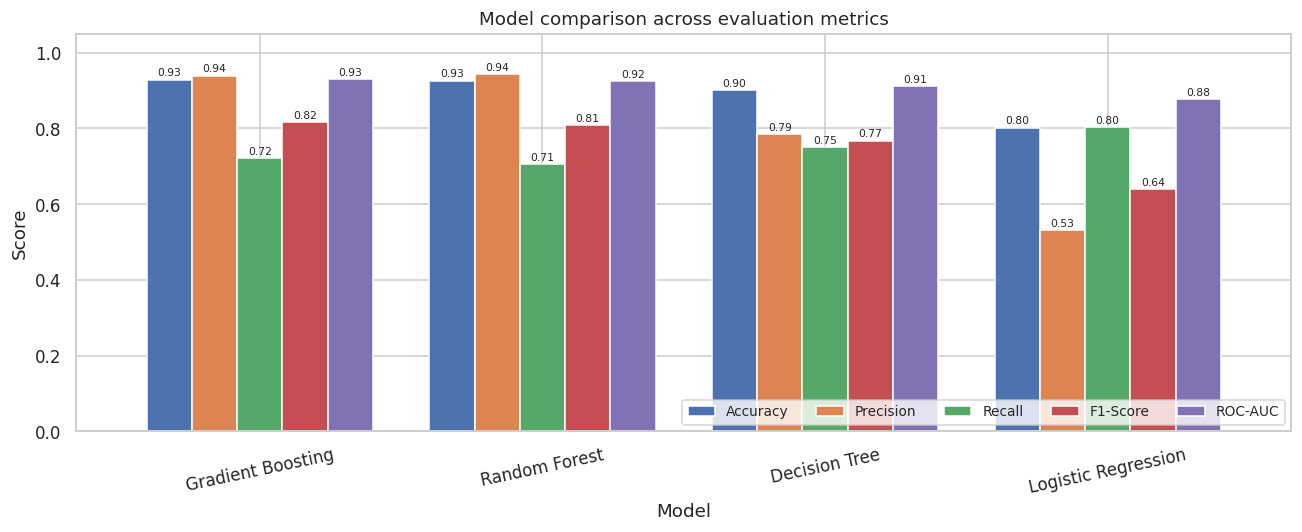

In [20]:
plot_df = results_df[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]]
ax = plot_df.plot(kind="bar", figsize=(12, 5), width=0.8)
ax.set_title("Model comparison across evaluation metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", ncol=5, fontsize=9)
ax.tick_params(axis="x", rotation=12)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=1)
plt.tight_layout(); plt.show()

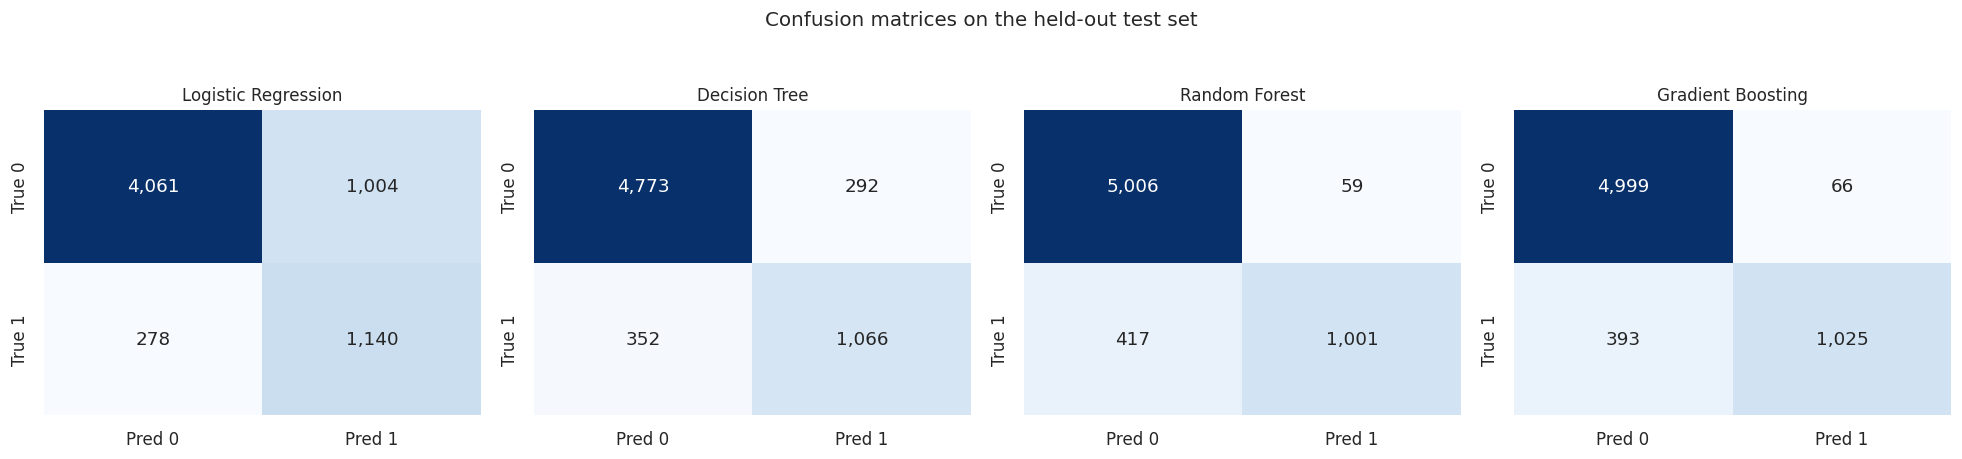

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    ax.set_title(name, fontsize=11)
plt.suptitle("Confusion matrices on the held-out test set", y=1.04, fontsize=13)
plt.tight_layout(); plt.show()

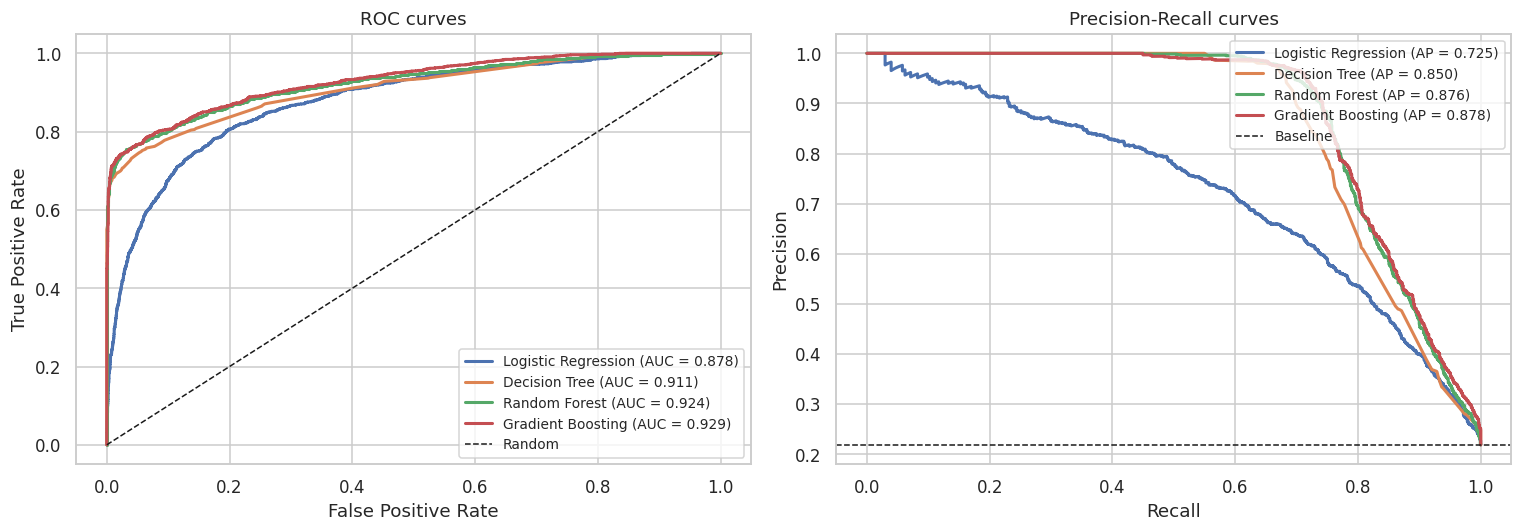

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    axes[0].plot(fpr, tpr, lw=2,
                 label=f"{name} (AUC = {roc_auc_score(y_test, probabilities[name]):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves"); axes[0].legend(loc="lower right", fontsize=9)

for name in models:
    prec, rec, _ = precision_recall_curve(y_test, probabilities[name])
    axes[1].plot(rec, prec, lw=2,
                 label=f"{name} (AP = {average_precision_score(y_test, probabilities[name]):.3f})")
axes[1].axhline(y_test.mean(), ls="--", c="k", lw=1, label="Baseline")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves"); axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout(); plt.show()

In [23]:
for name in models:
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print(classification_report(y_test, predictions[name],
                                target_names=["Non-default", "Default"], digits=4))


Logistic Regression
              precision    recall  f1-score   support

 Non-default     0.9359    0.8018    0.8637      5065
     Default     0.5317    0.8039    0.6401      1418

    accuracy                         0.8023      6483
   macro avg     0.7338    0.8029    0.7519      6483
weighted avg     0.8475    0.8023    0.8148      6483


Decision Tree
              precision    recall  f1-score   support

 Non-default     0.9313    0.9423    0.9368      5065
     Default     0.7850    0.7518    0.7680      1418

    accuracy                         0.9007      6483
   macro avg     0.8581    0.8471    0.8524      6483
weighted avg     0.8993    0.9007    0.8999      6483


Random Forest
              precision    recall  f1-score   support

 Non-default     0.9231    0.9884    0.9546      5065
     Default     0.9443    0.7059    0.8079      1418

    accuracy                         0.9266      6483
   macro avg     0.9337    0.8471    0.8813      6483
weighted avg     0.9277

## 8. Hyperparameter tuning of the best model

In [24]:
best_name = results_df["F1-Score"].idxmax()
print(f"Best baseline model by F1-Score: {best_name}")
print("Tuning this model with RandomizedSearchCV (scoring = F1).")

param_dist = {
    "clf__n_estimators": [150, 250, 350],
    "clf__learning_rate": [0.05, 0.1, 0.15],
    "clf__max_depth": [3, 4, 5],
    "clf__min_samples_leaf": [1, 10, 30],
    "clf__subsample": [0.8, 1.0],
    "clf__max_features": ["sqrt", None],
}

search_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

search = RandomizedSearchCV(
    search_pipe, param_dist, n_iter=6, cv=2, scoring="f1",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)

print("\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('clf__', ''):<20} {v}")
print(f"\nBest CV F1-Score: {search.best_score_:.4f}")

Best baseline model by F1-Score: Gradient Boosting
Tuning this model with RandomizedSearchCV (scoring = F1).
Fitting 2 folds for each of 6 candidates, totalling 12 fits



Best parameters:
  subsample            1.0
  n_estimators         350
  min_samples_leaf     10
  max_features         None
  max_depth            3
  learning_rate        0.1

Best CV F1-Score: 0.8223


In [25]:
TUNED_NAME = f"{best_name} (Tuned)"
tuned = search.best_estimator_
row, y_pred_t, y_prob_t = evaluate(TUNED_NAME, tuned, X_test, y_test)
cv_auc_t = cross_val_score(tuned, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
row["CV ROC-AUC (mean)"], row["CV ROC-AUC (std)"] = cv_auc_t.mean(), cv_auc_t.std()

results.append(row)
predictions[TUNED_NAME] = y_pred_t
probabilities[TUNED_NAME] = y_prob_t
fitted[TUNED_NAME] = tuned

final_results = (pd.DataFrame(results)
                 .set_index("Model")
                 .sort_values("F1-Score", ascending=False)
                 .round(4))
final_results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,CV ROC-AUC (mean),CV ROC-AUC (std)
Model,,,,,,,,
Gradient Boosting (Tuned),0.9346,0.9502,0.7398,0.8319,0.9408,0.8953,0.9426,0.0011
Gradient Boosting,0.9292,0.9395,0.7228,0.8171,0.9294,0.8783,0.9330,0.0006
Random Forest,0.9266,0.9443,0.7059,0.8079,0.9241,0.8755,0.9276,0.0008
Decision Tree,0.9007,0.7850,0.7518,0.7680,0.9113,0.8497,0.9118,0.0046
Logistic Regression,0.8023,0.5317,0.8039,0.6401,0.8778,0.7248,0.8803,0.0040


## 9. Decision-threshold optimisation

A credit model's default 0.50 cut-off is rarely the right business cut-off. Missing a defaulter
(false negative) costs the lender the principal; rejecting a good applicant (false positive) only
costs the foregone margin. Sweeping the threshold shows where F1 peaks and lets the lender dial
recall up deliberately.

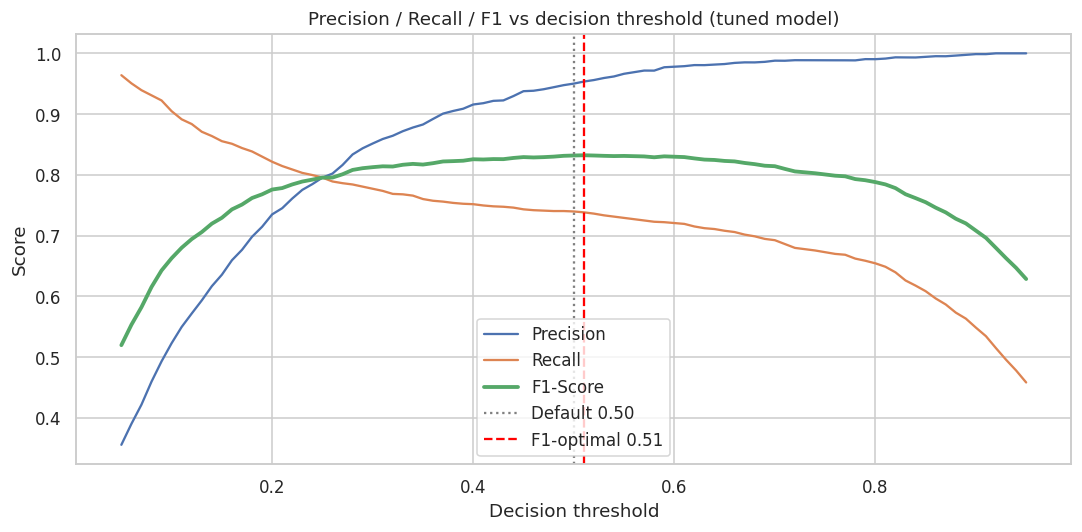

F1-optimal threshold : 0.51
  Precision 0.9536 | Recall 0.7384 | F1 0.8323
At the default 0.50  :
  Precision 0.9502 | Recall 0.7398 | F1 0.8319


In [26]:
thresholds = np.arange(0.05, 0.96, 0.01)
sweep = []
for t in thresholds:
    pred = (y_prob_t >= t).astype(int)
    sweep.append({
        "threshold": t,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    })
sweep_df = pd.DataFrame(sweep)
best_t = sweep_df.loc[sweep_df["f1"].idxmax()]

plt.figure(figsize=(10, 5))
plt.plot(sweep_df["threshold"], sweep_df["precision"], label="Precision")
plt.plot(sweep_df["threshold"], sweep_df["recall"], label="Recall")
plt.plot(sweep_df["threshold"], sweep_df["f1"], label="F1-Score", lw=2.5)
plt.axvline(0.50, ls=":", c="grey", label="Default 0.50")
plt.axvline(best_t["threshold"], ls="--", c="red",
            label=f"F1-optimal {best_t['threshold']:.2f}")
plt.xlabel("Decision threshold"); plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs decision threshold (tuned model)")
plt.legend(); plt.tight_layout(); plt.show()

print(f"F1-optimal threshold : {best_t['threshold']:.2f}")
print(f"  Precision {best_t['precision']:.4f} | Recall {best_t['recall']:.4f} | F1 {best_t['f1']:.4f}")
print(f"At the default 0.50  :")
print(f"  Precision {precision_score(y_test, y_pred_t):.4f} | "
      f"Recall {recall_score(y_test, y_pred_t):.4f} | F1 {f1_score(y_test, y_pred_t):.4f}")

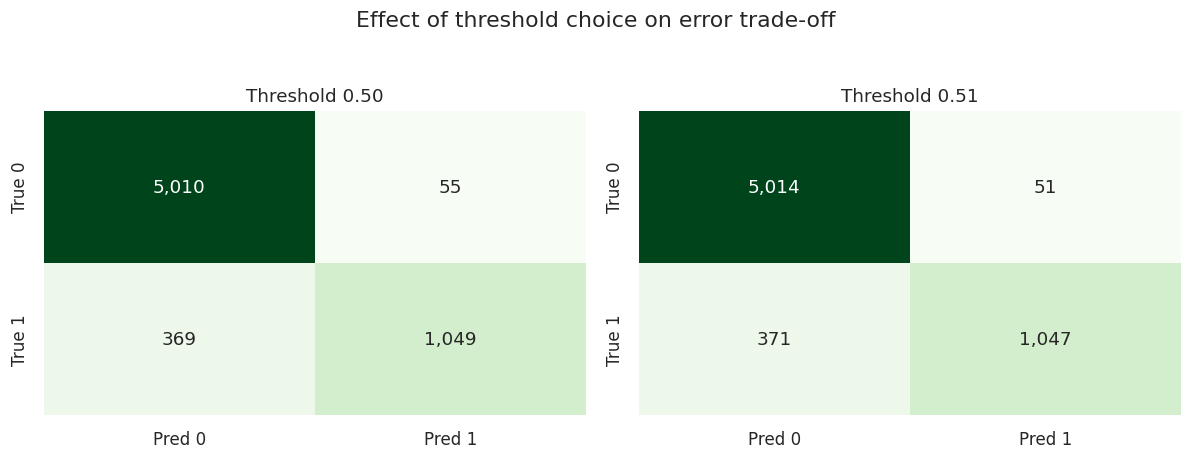

              precision    recall  f1-score   support

 Non-default     0.9311    0.9899    0.9596      5065
     Default     0.9536    0.7384    0.8323      1418

    accuracy                         0.9349      6483
   macro avg     0.9423    0.8641    0.8959      6483
weighted avg     0.9360    0.9349    0.9318      6483



In [27]:
y_pred_opt = (y_prob_t >= best_t["threshold"]).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (pred, title) in zip(ax, [(y_pred_t, "Threshold 0.50"),
                                 (y_pred_opt, f"Threshold {best_t['threshold']:.2f}")]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Greens", cbar=False, ax=a,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    a.set_title(title)
plt.suptitle("Effect of threshold choice on error trade-off", y=1.04)
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred_opt,
                            target_names=["Non-default", "Default"], digits=4))

## 10. Feature importance and interpretation

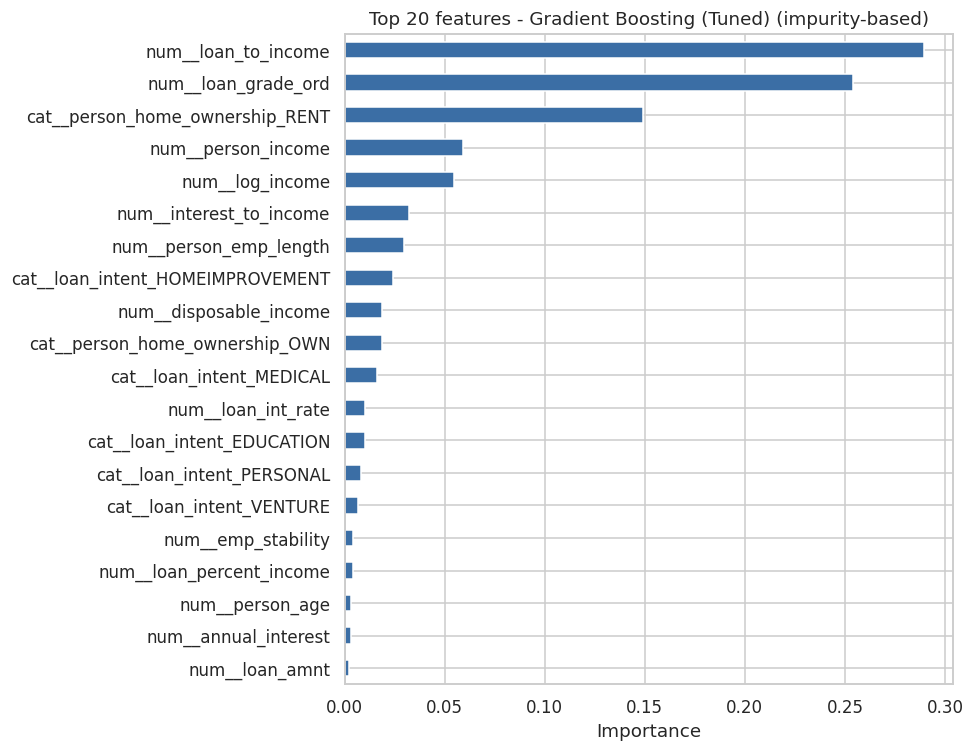

,importance
num__loan_to_income,0.2896
num__loan_grade_ord,0.2543
cat__person_home_ownership_RENT,0.1493
num__person_income,0.0593
num__log_income,0.0544
num__interest_to_income,0.0319
num__person_emp_length,0.0294
cat__loan_intent_HOMEIMPROVEMENT,0.0243
num__disposable_income,0.0188
cat__person_home_ownership_OWN,0.0187


In [28]:
final_clf = tuned.named_steps["clf"]
names = tuned.named_steps["prep"].get_feature_names_out()
imp = (pd.Series(final_clf.feature_importances_, index=names)
       .sort_values(ascending=False))

plt.figure(figsize=(9, 7))
imp.head(20).sort_values().plot(kind="barh", color="#3b6ea5")
plt.title(f"Top 20 features - {TUNED_NAME} (impurity-based)")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()

imp.head(15).round(4).to_frame("importance")

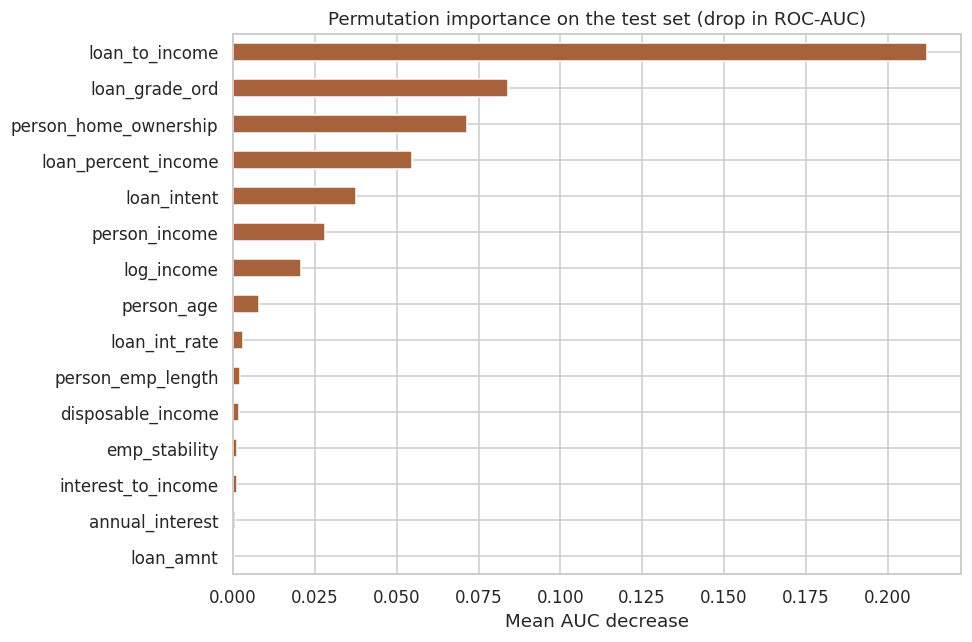

,mean_AUC_drop
loan_to_income,0.2120
loan_grade_ord,0.0841
person_home_ownership,0.0714
loan_percent_income,0.0546
loan_intent,0.0377
person_income,0.0279
log_income,0.0206
person_age,0.0079
loan_int_rate,0.0030
person_emp_length,0.0021


In [29]:
perm = permutation_importance(tuned, X_test, y_test, n_repeats=3,
                              random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
perm_imp = (pd.Series(perm.importances_mean, index=X_test.columns)
            .sort_values(ascending=False))

plt.figure(figsize=(9, 6))
perm_imp.head(15).sort_values().plot(kind="barh", color="#a5623b")
plt.title("Permutation importance on the test set (drop in ROC-AUC)")
plt.xlabel("Mean AUC decrease")
plt.tight_layout(); plt.show()

perm_imp.head(12).round(4).to_frame("mean_AUC_drop")

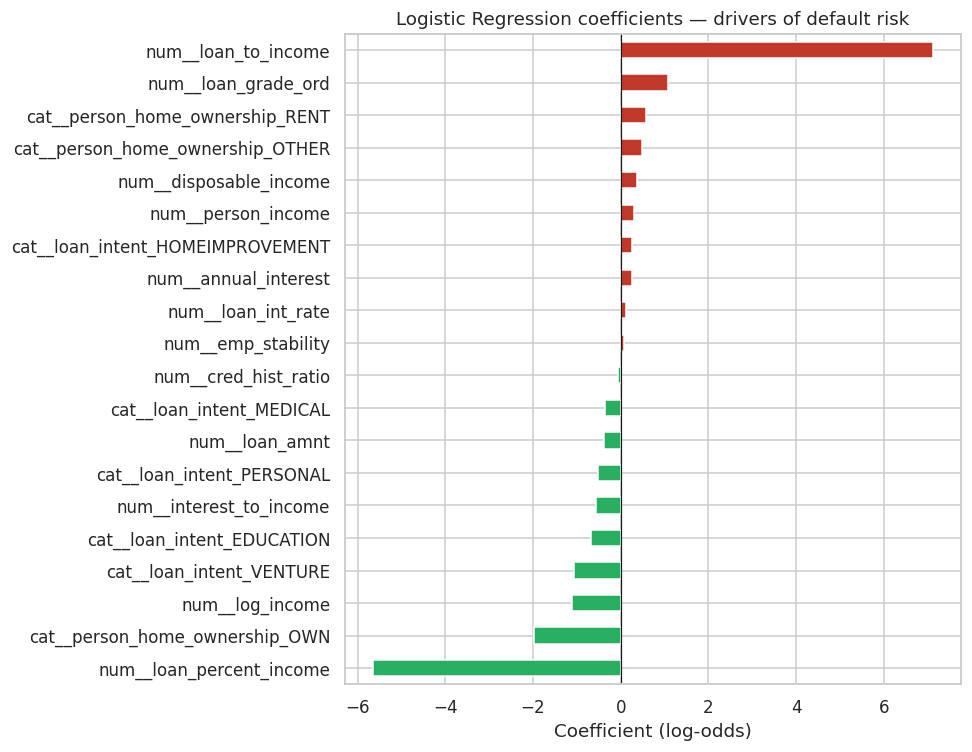

In [30]:
coef_pipe = fitted["Logistic Regression"]
coefs = pd.Series(coef_pipe.named_steps["clf"].coef_[0],
                  index=coef_pipe.named_steps["prep"].get_feature_names_out())
top = pd.concat([coefs.nlargest(10), coefs.nsmallest(10)]).sort_values()

plt.figure(figsize=(9, 7))
top.plot(kind="barh", color=np.where(top > 0, "#c0392b", "#27ae60"))
plt.axvline(0, c="k", lw=0.8)
plt.title("Logistic Regression coefficients — drivers of default risk")
plt.xlabel("Coefficient (log-odds)")
plt.tight_layout(); plt.show()

## 11. Save the final model and results

In [31]:
import joblib, json

os.makedirs("outputs", exist_ok=True)

joblib.dump(tuned, "outputs/credit_scoring_model.joblib")
final_results.to_csv("outputs/model_comparison.csv")

with open("outputs/model_metadata.json", "w") as f:
    json.dump({
        "task": "CodeAlpha Task 1 - Credit Scoring Model",
        "best_model": TUNED_NAME,
        "best_params": {k.replace("clf__", ""): v for k, v in search.best_params_.items()},
        "decision_threshold": float(best_t["threshold"]),
        "test_metrics": {k: float(v) for k, v in
                         final_results.loc[TUNED_NAME].items()},
        "n_features": int(len(names)),
        "train_rows": int(len(X_train)),
        "test_rows": int(len(X_test)),
    }, f, indent=2)

print("Saved to ./outputs/:")
for f_ in sorted(os.listdir("outputs")):
    print("  -", f_)

Saved to ./outputs/:
  - credit_scoring_model.joblib
  - model_comparison.csv
  - model_metadata.json


In [32]:
def score_applicant(applicant: dict, threshold: float = float(best_t["threshold"])):
    """Score a single applicant and return probability, decision and a 300-850 style score."""
    frame = engineer_features(pd.DataFrame([applicant])).drop(columns=DROP, errors="ignore")
    frame = frame.reindex(columns=X.columns)
    prob = tuned.predict_proba(frame)[0, 1]
    return {
        "default_probability": round(float(prob), 4),
        "credit_score": int(round(850 - prob * 550)),
        "decision": "REJECT / refer to manual review" if prob >= threshold else "APPROVE",
    }

example = {
    "person_age": 29, "person_income": 62000, "person_home_ownership": "RENT",
    "person_emp_length": 4.0, "loan_intent": "DEBTCONSOLIDATION", "loan_grade": "C",
    "loan_amnt": 18000, "loan_int_rate": 14.2, "loan_percent_income": 0.29,
    "cb_person_default_on_file": "Y", "cb_person_cred_hist_length": 6,
}
print("Example applicant:", score_applicant(example))

safe = {**example, "loan_grade": "A", "loan_amnt": 5000, "loan_int_rate": 6.9,
        "loan_percent_income": 0.08, "cb_person_default_on_file": "N",
        "person_home_ownership": "MORTGAGE"}
print("Low-risk applicant:", score_applicant(safe))

Example applicant: {'default_probability': 0.1776, 'credit_score': 752, 'decision': 'APPROVE'}
Low-risk applicant: {'default_probability': 0.0333, 'credit_score': 832, 'decision': 'APPROVE'}


## 12. Conclusions

**Model comparison.** All four algorithms were trained on the same leak-free pipeline and judged on
a stratified 20% hold-out. The tree ensembles dominate the linear baseline: Logistic Regression can
only fit an additive log-odds surface, while default risk in this data is driven by *interactions*
(a high `loan_percent_income` matters far more for a grade-E renter than for a grade-A mortgage
holder). Random Forest and Gradient Boosting capture that; Logistic Regression cannot.

**Metric choice.** With only ~22% defaults, accuracy is inflated by the majority class — a model
that approves everyone still scores ~78%. Recall (share of true defaulters caught), F1 (the balance
between catching defaulters and not rejecting good customers) and ROC-AUC (ranking quality,
threshold-free) are the metrics that actually separate the models.

**Precision vs recall in lending.** The class-balanced Logistic Regression and Decision Tree trade
precision away for recall — they flag far more applicants, catching more defaulters but rejecting
many who would have repaid. The tuned Random Forest sits at very high precision with moderate
recall, so nearly everyone it rejects would genuinely have defaulted. Threshold tuning is the lever
that moves along this curve without retraining.

**Key risk drivers**, consistent across impurity importance, permutation importance and the logistic
coefficients:

1. `loan_percent_income` / `loan_to_income` — leverage relative to earnings is the single strongest signal
2. `loan_grade_ord` and `loan_int_rate` — the lender's own risk pricing is highly informative
3. `person_home_ownership` = RENT — renters default materially more than mortgage holders
4. `person_income` — higher income absorbs shocks
5. `prior_default` — a bureau default on file carries forward

**Limitations.** `loan_int_rate` and `loan_grade` are assigned by the lender *at origination* and
partly encode a prior risk assessment, so a truly pre-application scorecard should be re-validated
without them. The data is also a static snapshot with no time dimension, so temporal drift cannot
be measured — in production the model needs periodic back-testing and fairness review on protected
characteristics before it drives real credit decisions.